In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup

In [2]:
url = "https://books.toscrape.com/"

In [3]:
response = requests.get(url)

In [4]:
page_element = BeautifulSoup(response.text, "html.parser")

In [5]:
product_elements = page_element.select("article.product_pod")

In [15]:
### AUTOMATICALLY GRADED TASK
def get_image_url(product_element):
    "Get the URL of the image from the given product element using BeautifulSoup."

    # YOUR CODE HERE
    image_tag = product_element.select_one("div.image_container img")
    return image_tag["src"]

In [16]:
### TEST
assert get_image_url(product_elements[0]) == "media/cache/2c/da/2cdad67c44b002e7ead0cc35693c0e8b.jpg"

In [24]:
### AUTOMATICALLY GRADED TASK
def get_rating(product_element):
    "Get the rating (1-5) of the given product element."

    # YOUR CODE HERE
    rating_map = {
        "One": 1,
        "Two": 2,
        "Three": 3,
        "Four": 4,
        "Five": 5
    }

    p_tag = product_element.select_one("p.star-rating")
    rating_classes = p_tag["class"]
    rating_str = rating_classes[1]
    
    return rating_map[rating_str]

In [25]:
### TEST
assert get_rating(product_elements[0]) == 3

In [26]:
### AUTOMATICALLY GRADED TASK
def get_title(product_element):
    "Get the full-length title of the given product element."

    # YOUR CODE HERE
    a_tag = product_element.select_one("h3 a")
    return a_tag["title"]

In [27]:
### TEST
assert get_title(product_elements[0]) == "A Light in the Attic"

In [34]:
def get_price(product_element):
    "Get the price of the given product element."

    # YOUR CODE HERE
    price_str = product_element.select_one("p.price_color").get_text()
    cleaned_str = price_str.replace("£", "").replace("Â", "")
    return float(cleaned_str)

In [35]:
### TEST
assert get_price(product_elements[0]) == 51.77

In [42]:
def get_attributes(product_element):
    return {
        "image_url": get_image_url(product_element),
        "rating": get_rating(product_element),
        "title": get_title(product_element),
        "price": get_price(product_element),
    }

In [43]:
get_attributes(product_elements[0])

{'image_url': 'media/cache/2c/da/2cdad67c44b002e7ead0cc35693c0e8b.jpg',
 'rating': 3,
 'title': 'A Light in the Attic',
 'price': 51.77}

In [44]:
product_data = [get_attributes(product_element) for product_element in product_elements]

In [45]:
df = pd.DataFrame(product_data)

In [46]:
df.head()

,image_url,rating,title,price
0,media/cache/2c/da/2cdad67c44b002e7ead0cc35693c...,3,A Light in the Attic,51.77
1,media/cache/26/0c/260c6ae16bce31c8f8c95daddd9f...,1,Tipping the Velvet,53.74
2,media/cache/3e/ef/3eef99c9d9adef34639f51066202...,1,Soumission,50.10
3,media/cache/32/51/3251cf3a3412f53f339e42cac213...,4,Sharp Objects,47.82
4,media/cache/be/a5/bea5697f2534a2f86a3ef27b5a8c...,5,Sapiens: A Brief History of Humankind,54.23


In [47]:
 # df = pd.read_csv("products.csv")

In [48]:
### MANUALLY GRADED TASK
def plot_counts_by_rating(df):
    "Plot the count of products by rating."""

    # YOUR CODE HERE
    sns.countplot(data=df, x='rating')
    plt.title('Count of Products by Rating')
    plt.xlabel('Rating')
    plt.ylabel('Number of Products')
    plt.show()

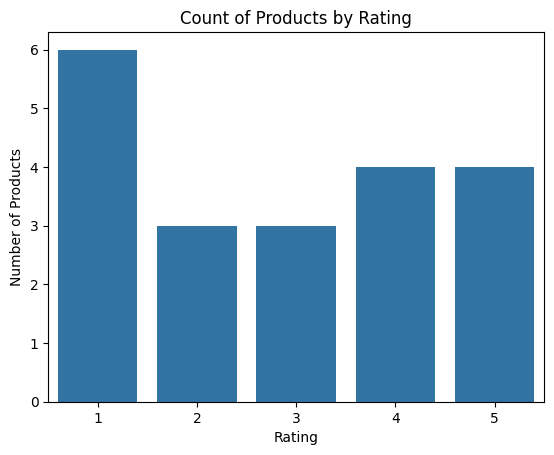

In [49]:
plot_counts_by_rating(df)

In [50]:
### MANUALLY GRADED TASK
def plot_price_distribution(df):
    """Plot the price distribution of the products."""

    # YOUR CODE HERE
    sns.histplot(data=df, x='price', kde=True)
    plt.title('Distribution of Product Prices')
    plt.xlabel('Price')
    plt.ylabel('Frequency')
    plt.show()

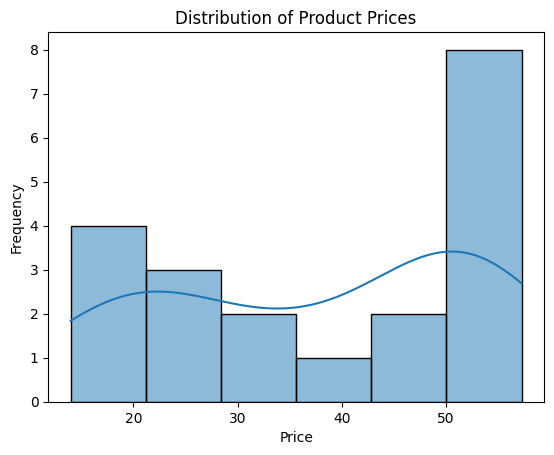

In [51]:
plot_price_distribution(df)

In [52]:
### MANUALLY GRADED TASK
def plot_title_length_distribution(df):
    """Plot the distribution of the title lengths."""

    # YOUR CODE HERE
    df['title_length'] = df['title'].str.len()
    
    sns.histplot(data=df, x='title_length', kde=True)
    plt.title('Distribution of Product Title Lengths')
    plt.xlabel('Title Length')
    plt.ylabel('Frequency')
    plt.show()

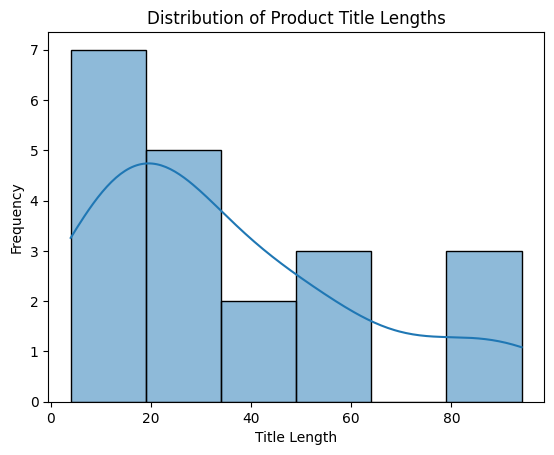

In [53]:
plot_title_length_distribution(df)

In [54]:
### MANUALLY GRADED ANSWER
def plot_price_distribution_per_rating(df):
    """Plot the price distribution of the products per rating."""

    # YOUR CODE HERE
    sns.boxplot(data=df, x='rating', y='price')
    plt.title('Price Distribution per Rating')
    plt.xlabel('Rating')
    plt.ylabel('Price')
    plt.show()

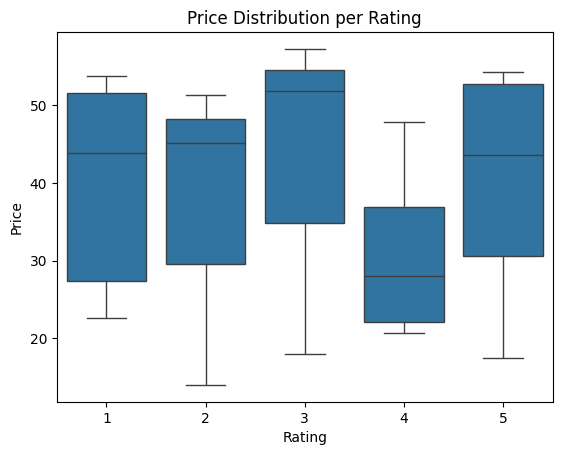

In [55]:
plot_price_distribution_per_rating(df)

In [56]:
### MANUALLY GRADED ANSWER
def plot_corr_heat_map(df):
    """Plot the Pearson correlation between the numeric variables in the dataset using a heat map."""

    # YOUR CODE HERE
    if 'title_length' not in df.columns:
         df['title_length'] = df['title'].str.len()
            
    numeric_df = df.select_dtypes(include=['int64', 'float64'])
    
    corr = numeric_df.corr(method='pearson')
    
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Pearson Correlation Heatmap')
    plt.show()

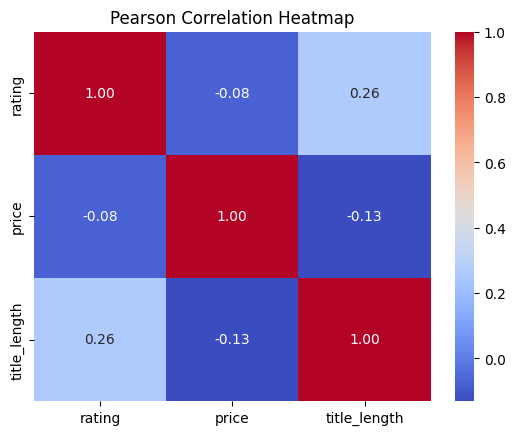

In [57]:
plot_corr_heat_map(df)

In [58]:
### MANUALLY GRADED ANSWER
def compute_descriptive_stats_for_price_per_rating(df):
    """
    Compute the `count`, `mean`, `std`, `min`, `25% quantile`, `median`, `75% quantile`, and `max` statistics
    for the product's prices per rating (1-5). Return them as a `pandas.DataFrame`.
    """

    # YOUR CODE HERE
    return df.groupby('rating')['price'].describe()

In [59]:
compute_descriptive_stats_for_price_per_rating(df)

,count,mean,std,min,25%,50%,75%,max
rating,,,,,,,,
1,6.0,40.018333,14.178174,22.65,27.3075,43.845,51.6375,53.74
2,3.0,36.830000,20.018382,13.99,29.5800,45.170,48.2500,51.33
3,3.0,42.316667,21.296472,17.93,34.8500,51.770,54.5100,57.25
4,4.0,31.105000,12.460865,20.66,22.1150,27.970,36.9600,47.82
5,4.0,39.750000,17.186613,17.46,30.6300,43.655,52.7750,54.23
